In [1]:
#%%
# Standard library imports
from argparse import ArgumentParser
import shutil
import os, sys
# VENV_PATH = "/Users/harshit/Documents/UWM/F25/799-IS/Lagrangian_caVAE-main/.venv/lib/python3.9/site-packages"
# if VENV_PATH not in sys.path:
#     sys.path.append(VENV_PATH)

# import pytorch_lightning as pl
# print(f"Success! Lightning Version: {pl.__version__}")
# print(sys.executable)
THIS_DIR = os.path.abspath('')
PARENT_DIR = os.path.dirname(os.path.abspath(''))
sys.path.append(PARENT_DIR)
# import pysr
import torch
import pytorch_lightning as pl
import sys
import os

print(f"Python Executable: {sys.executable}")
print(f"Torch Location:    {os.path.dirname(torch.__file__)}")
print(f"Lightning Location:{os.path.dirname(pl.__file__)}")

# Prediction:
# Torch      -> /Users/harshit/miniconda3/lib/... (The working one)
# Lightning  -> .../.venv/lib/... (The library you need)
# Third party imports
import torch
from torch.nn import functional as F
from torch.utils.data import DataLoader
import pytorch_lightning as pl
from pytorch_lightning import Trainer, seed_everything
from pytorch_lightning.callbacks import ModelCheckpoint
from torchdiffeq import odeint
from torchvision import utils
import matplotlib.pyplot as plt
import numpy as np

# local application imports
from lag_caVAE.lag import Lag_Net
from lag_caVAE.nn_models import MLP_Encoder, MLP, MLP_Decoder, PSD
from hyperspherical_vae.distributions import VonMisesFisher
from hyperspherical_vae.distributions import HypersphericalUniform
from utils import arrange_data, from_pickle, my_collate, ImageDataset
from examples.pend_lag_cavae_trainer import Model

seed_everything(0)
%matplotlib inline
DPI = 600
import torch
print(f"I thought I was using 1.6.0, but I am actually using: {torch.__version__}")

/Users/harshit/miniconda3/envs/lagrangian_clean/lib/python3.9/site-packages/pytorch_lightning/loggers/tensorboard.py:12: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


Python Executable: /Users/harshit/miniconda3/envs/lagrangian_clean/bin/python
Torch Location:    /Users/harshit/miniconda3/envs/lagrangian_clean/lib/python3.9/site-packages/torch
Lightning Location:/Users/harshit/miniconda3/envs/lagrangian_clean/lib/python3.9/site-packages/pytorch_lightning
I thought I was using 1.6.0, but I am actually using: 2.8.0


## Load Model

In [2]:
checkpoint_path = os.path.join(PARENT_DIR, 
                               'results', 
                               'pend',
                               'pend-lag-cavae-T_p=8-epoch=985-step=5915.ckpt')

# checkpoint_path = os.path.join(PARENT_DIR, 
#                                'results', 
#                                'pend',
#                                'pend-lag-cavae-T_p=4-epoch=829-step=6639.ckpt')

model = Model.load_from_checkpoint(checkpoint_path)

In [3]:
ckpt = torch.load(checkpoint_path, map_location="cpu")
ckpt.keys()

dict_keys(['epoch', 'global_step', 'pytorch-lightning_version', 'state_dict', 'callbacks', 'optimizer_states', 'lr_schedulers', 'hparams_name', 'hyper_parameters'])

In [4]:
print(ckpt['callbacks'])

{"ModelCheckpoint{'monitor': 'monitor', 'mode': 'min', 'every_n_train_steps': 0, 'every_n_epochs': 1, 'train_time_interval': None, 'save_on_train_epoch_end': True}": {'monitor': 'monitor', 'best_model_score': tensor(26.3525), 'best_model_path': '/var/lib/condor/execute/slot1/dir_4181402/scratch/Lagrangian_caVAE-main/logs/pend-lag-cavae/lightning_logs/version_0/checkpoints/pend-lag-cavae-T_p=8-epoch=985-step=5915.ckpt', 'current_score': tensor(26.3525), 'dirpath': '/var/lib/condor/execute/slot1/dir_4181402/scratch/Lagrangian_caVAE-main/logs/pend-lag-cavae/lightning_logs/version_0/checkpoints', 'best_k_models': {'/var/lib/condor/execute/slot1/dir_4181402/scratch/Lagrangian_caVAE-main/logs/pend-lag-cavae/lightning_logs/version_0/checkpoints/pend-lag-cavae-T_p=8-epoch=985-step=5915.ckpt': tensor(26.3525)}, 'kth_best_model_path': '/var/lib/condor/execute/slot1/dir_4181402/scratch/Lagrangian_caVAE-main/logs/pend-lag-cavae/lightning_logs/version_0/checkpoints/pend-lag-cavae-T_p=8-epoch=985-st

In [5]:
dict(model.named_modules())

{'': Model(
   (loss_fn): MSELoss()
   (recog_q_net): MLP_Encoder(
     (linear1): Linear(in_features=1024, out_features=300, bias=True)
     (linear2): Linear(in_features=300, out_features=300, bias=True)
     (linear4): Linear(in_features=300, out_features=3, bias=True)
   )
   (obs_net): MLP_Encoder(
     (linear1): Linear(in_features=1, out_features=100, bias=True)
     (linear2): Linear(in_features=100, out_features=100, bias=True)
     (linear4): Linear(in_features=100, out_features=1024, bias=True)
   )
   (ode): Lag_Net(
     (g_net): MLP(
       (linear1): Linear(in_features=2, out_features=50, bias=True)
       (linear2): Linear(in_features=50, out_features=50, bias=True)
       (linear3): Linear(in_features=50, out_features=1, bias=True)
     )
     (M_net): PSD(
       (linear1): Linear(in_features=2, out_features=50, bias=True)
       (linear2): Linear(in_features=50, out_features=50, bias=True)
       (linear3): Linear(in_features=50, out_features=1, bias=True)
     )
   

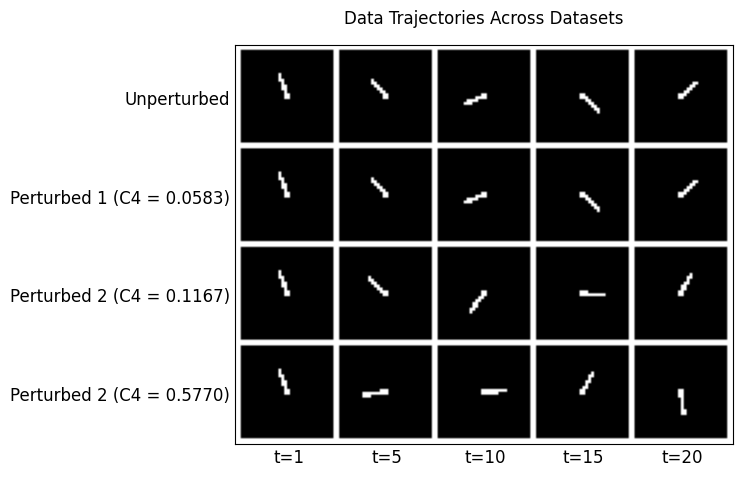

In [24]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision import utils
from torch.utils.data import DataLoader

# Ensure the names match your desired datasets in the 'datasets' folder
datasets_info = {
    'Unperturbed': 'pendulum-gym-image-dataset-train-reverse-angle-perturbed-poly-cubic.pkl',
    'Perturbed 1 (C4 = 0.0583)': 'pendulum-gym-image-dataset-train-reverse-angle-perturbed-poly-cubic.pkl',
    'Perturbed 2 (C4 = 0.1167)': 'pendulum-gym-image-dataset-train-reverse-angle-perturbed-poly-cubic-med-2250.pkl',
    'Perturbed 2 (C4 = 0.5770)': 'pendulum-gym-image-dataset-train-reverse-angle-perturbed-poly-cubic-large.pkl',
}

b_ind = 0
# Array of indices representing the 1st, 5th, 10th, 15th, and 20th timestamps.
# (Since the trajectory length is 20, valid indices are 0 to 19)
timesteps = [0, 4, 9, 14, 19]

images_to_stack = []
valid_labels = []

for name, fname in datasets_info.items():
    d_path = os.path.join(PARENT_DIR, 'datasets', fname)
    if not os.path.exists(d_path):
        print(f"Dataset not found: {fname}")
        continue
        
    ds = ImageDataset(d_path, 19, ctrl=True)
    # Using batch_size=256 similar to the testing dataloader config
    dl = DataLoader(ds, batch_size=256, shuffle=False, collate_fn=my_collate)
    
    # Extract the first batch
    X, u = next(iter(dl))
    
    # Extract the exact timestamps for the specific batch_idx
    # X shape generally [20, 256, H, W]
    selected_X = X[timesteps, b_ind]
    
    # Ensure standard [N, C, H, W] shape for the grid
    selected_X = selected_X.view(len(timesteps), 1, 32, 32)
    
    images_to_stack.append(selected_X)
    valid_labels.append(name)

# Concatenate vertically into a single tensor
# Shape: [num_datasets * len(timesteps), 1, 32, 32]
all_images = torch.cat(images_to_stack, dim=0) 

# Create the grid; setting nrow to the number of columns (timesteps) forces 
# each dataset's sequence to take up exactly one horizontal row.
grid = utils.make_grid(all_images, nrow=len(timesteps), padding=2, pad_value=1.0)

fig, ax = plt.subplots(figsize=(1.5 * len(timesteps), 1.5 * len(valid_labels)))

# Pre-process grid for matplotlib (H, W, C) and clip colors cleanly 
# to avoid matplotlib "[0..1] range" warnings
image_grid = grid.permute(1, 2, 0).detach().cpu().numpy()
image_grid = np.clip(image_grid, 0.0, 1.0)

ax.imshow(image_grid)
ax.tick_params(axis='both', which='both', length=0)

# Position ticks right in the center of the rendered images.
# Initial padding is 2px, plus half the image size (16px), stepping by (32px + 2px)
x_ticks = [18 + i * 34 for i in range(len(timesteps))]
y_ticks = [18 + i * 34 for i in range(len(valid_labels))]

ax.set_xticks(x_ticks)
ax.set_xticklabels([f't={t+1}' for t in timesteps], fontsize=12)

ax.set_yticks(y_ticks)
ax.set_yticklabels(valid_labels, fontsize=12)

ax.set_title(f"Data Trajectories Across Datasets", pad=15)
plt.tight_layout()
plt.show()


## Prepare data

In [ ]:
data_path=os.path.join(PARENT_DIR, 'datasets', 'pendulum-gym-image-dataset-test-reverse-angle-stable-down-2.pkl')
print(data_path)
test_dataset = ImageDataset(data_path, 19, ctrl=True)

test_dataloader = DataLoader(test_dataset, batch_size=256, shuffle=False, collate_fn=my_collate)

In [3]:
# test_batch = next(iter(test_dataloader))
# X, u = test_batch
# print(torch.unique(u))

In [10]:
for i, batch in enumerate(test_dataloader):
    X, u = batch
    
    # Calculate unique values for the current batch
    unique_vals = torch.unique(u)
    
    print(f"Batch {i}: Unique u values are {unique_vals}")

all_batches = list(test_dataloader)
X, u = all_batches[0]
print(torch.unique(u))

Batch 0: Unique u values are tensor([0.])
tensor([0.])


In [11]:
# model.t_eval = torch.from_numpy(test_dataset.t_eval)
def extend_t_eval(t_eval, N_new):
    t_eval = np.asarray(t_eval)
    dt = t_eval[1] - t_eval[0]
    t0 = t_eval[0]
    return t0 + dt * np.arange(N_new)
t_eval = torch.from_numpy(test_dataset.t_eval)
extended = torch.tensor(extend_t_eval(t_eval, 60))
model.t_eval = extended
model.hparams.solver = 'rk4'
model(X, u)

/Users/harshit/miniconda3/envs/lagrangian_clean/lib/python3.9/site-packages/torch/distributions/distribution.py:62: UserWarning: <class 'hyperspherical_vae.distributions.hyperspherical_uniform.HypersphericalUniform'> does not define `arg_constraints`. Please set `arg_constraints = {}` or initialize the distribution with `validate_args=False` to turn off validation.
  warnings.warn(
/Users/harshit/miniconda3/envs/lagrangian_clean/lib/python3.9/site-packages/torch/nn/functional.py:5163: UserWarning: Default grid_sample and affine_grid behavior has changed to align_corners=False since 1.3.0. Please specify align_corners=True if the old behavior is desired. See the documentation of grid_sample for details.
  warnings.warn(
/Users/harshit/miniconda3/envs/lagrangian_clean/lib/python3.9/site-packages/torch/nn/functional.py:5096: UserWarning: Default grid_sample and affine_grid behavior has changed to align_corners=False since 1.3.0. Please specify align_corners=True if the old behavior is des

torch.Size([20, 256, 32, 32])


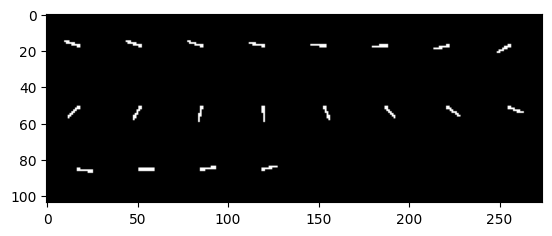

In [13]:
# data trajectory
b_ind = 0
print(X.shape)
grid = utils.make_grid(X[:, b_ind].view(-1, 1, 32, 32))
plt.imshow(grid.permute(1,2,0).detach().cpu().numpy())

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.19183391..1.4241728].


torch.Size([60, 256, 32, 32])


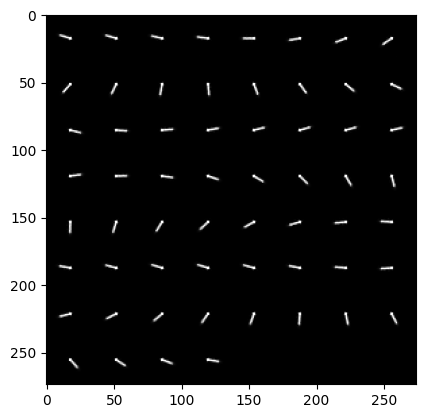

In [14]:
# prediction trajectory
print(model.Xrec.shape)
grid = utils.make_grid(model.Xrec[:, b_ind].view(-1, 1, 32, 32))
plt.imshow(grid.permute(1,2,0).detach().cpu().numpy())

## Plot learned potential energy

In [15]:
q = np.linspace(0, 2*np.pi, 41)
cos_q = np.cos(q[:-1])
sin_q = np.sin(q[:-1])
cos_q_sin_q = np.stack((cos_q, sin_q), axis=1)
cos_q_sin_q = torch.tensor(cos_q_sin_q, dtype=torch.float32)

Text(0, 0.5, '$V(\\phi)$')

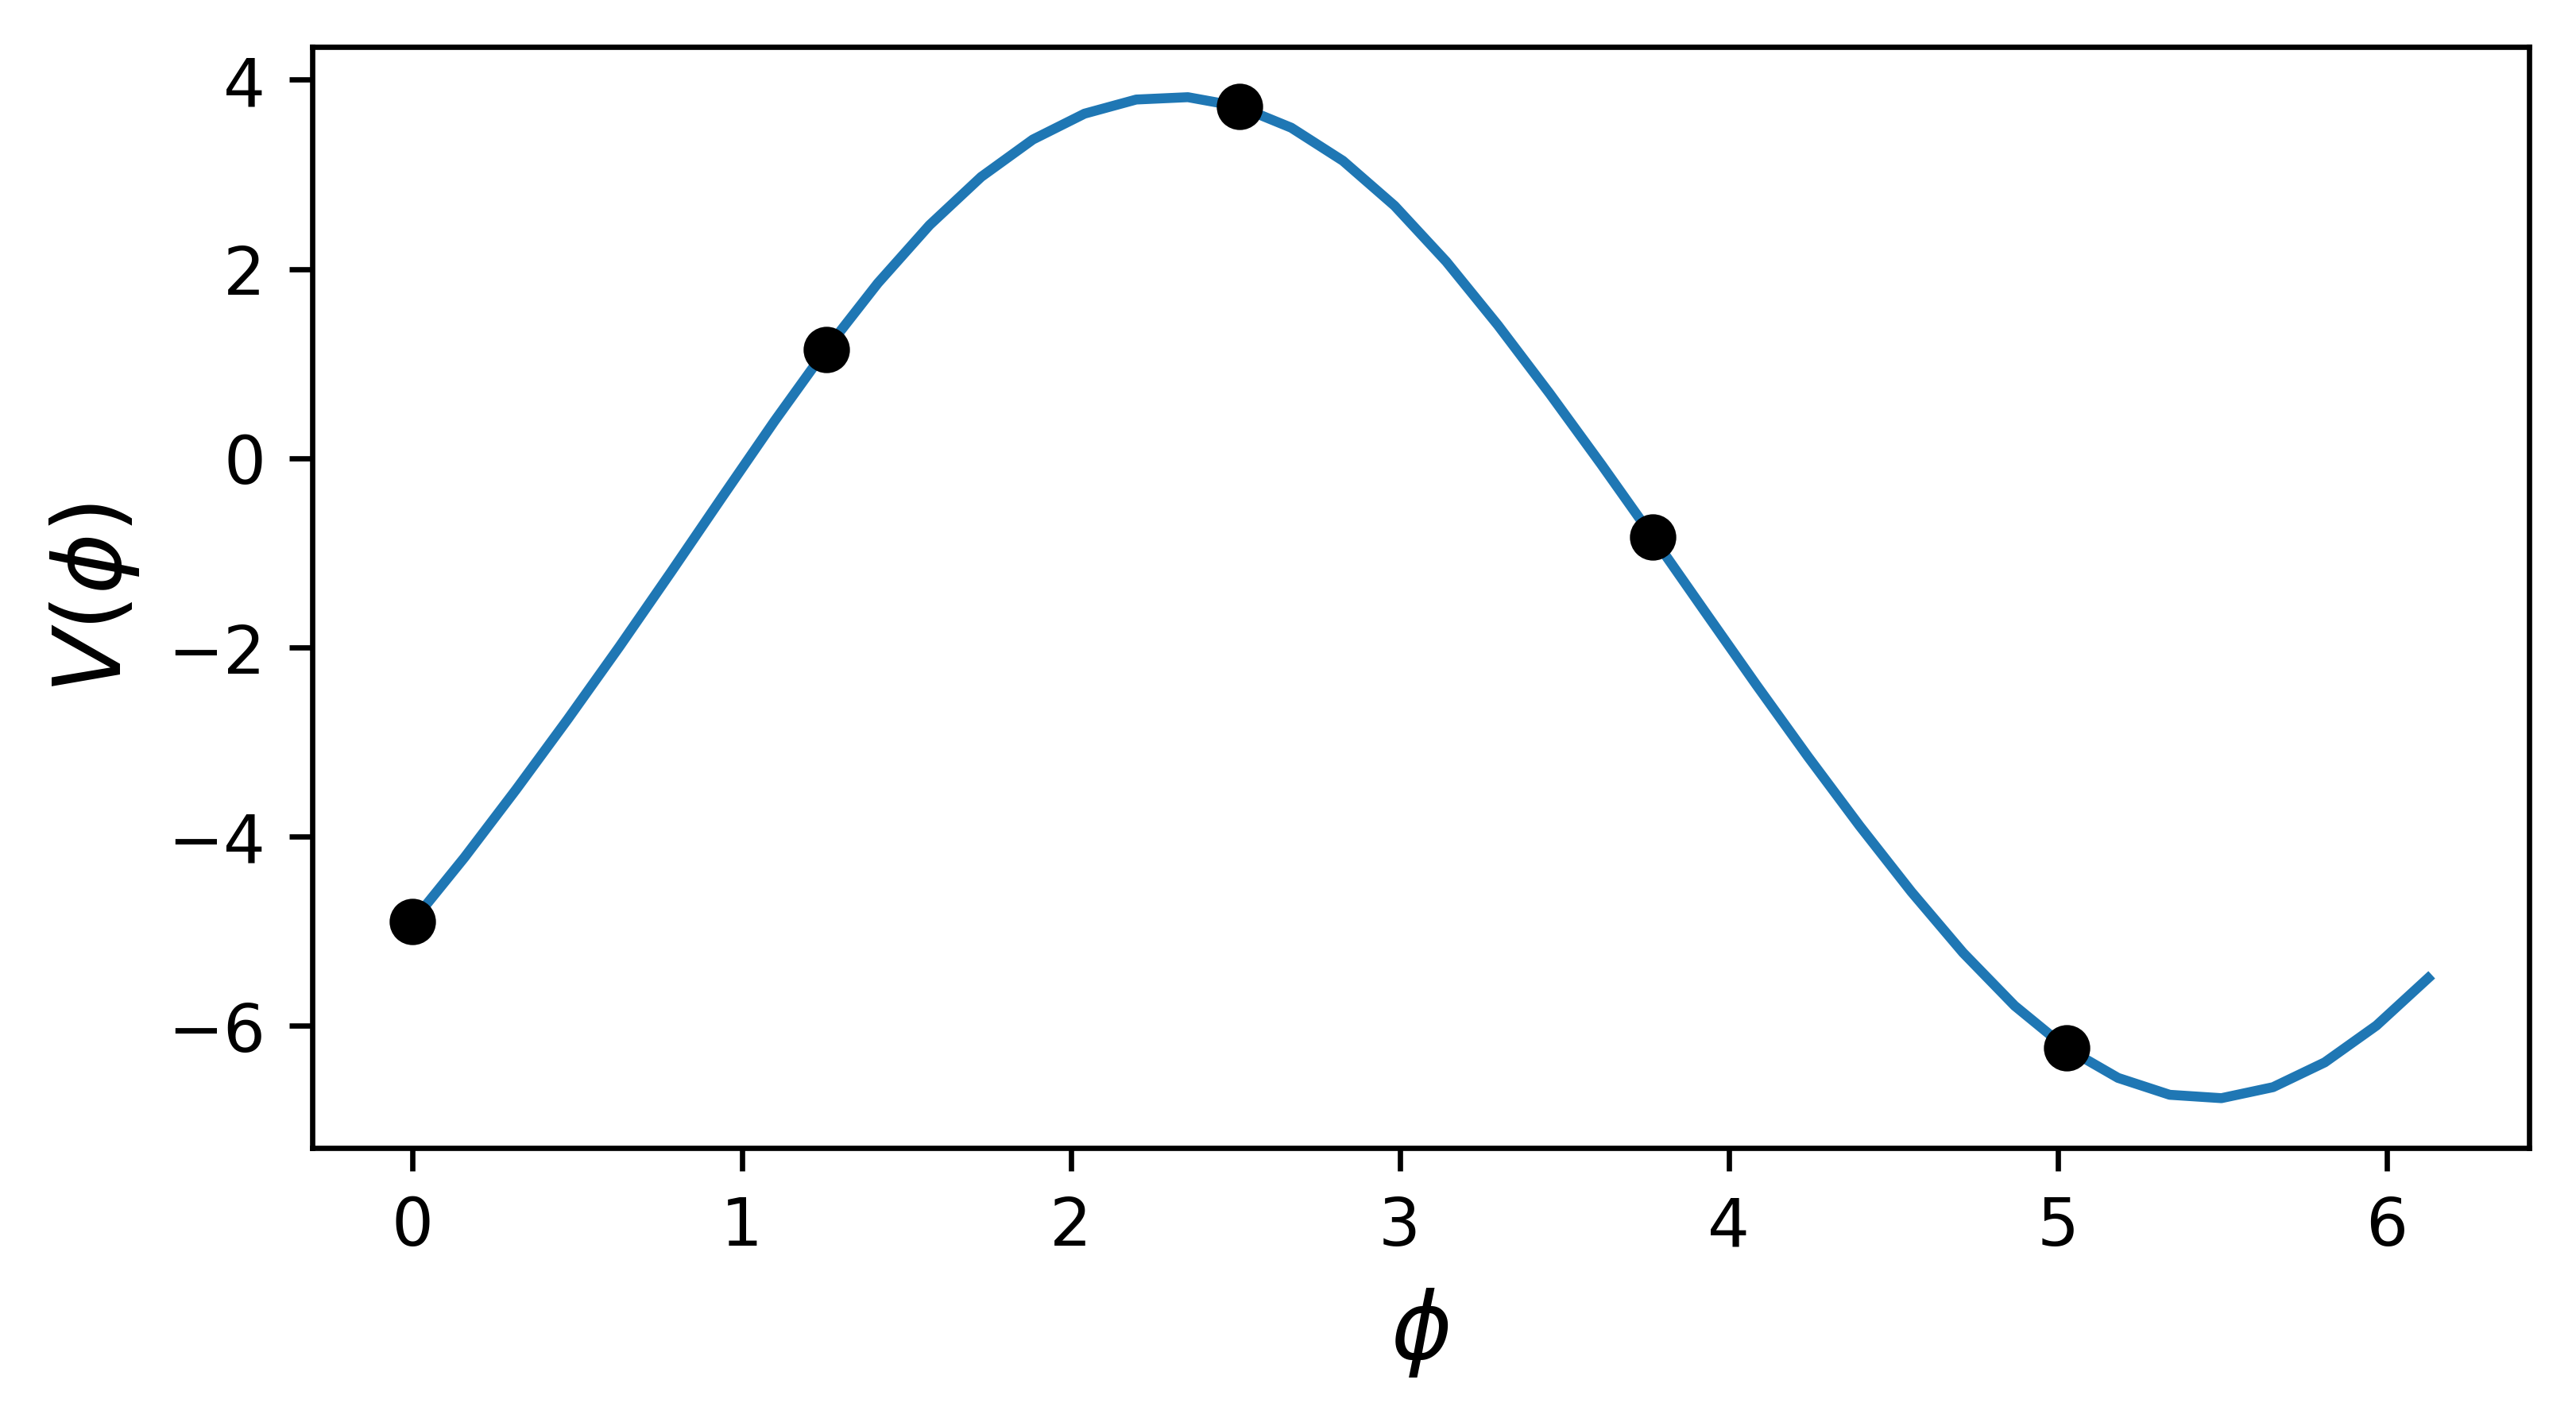

In [16]:
V_q = model.ode.V_net(cos_q_sin_q).detach().cpu().numpy()
fig = plt.figure(figsize=[6, 3], dpi=DPI)
markers_on = [0, 8, 16, 24, 32]
plt.plot(q[:-1], V_q, marker = 'o', markevery=markers_on, markerfacecolor=(0,0,0,1), markeredgecolor=(0,0,0,1))
plt.xlabel(r"$\phi$", fontsize=14)
plt.ylabel(r"$V(\phi)$", fontsize=14)
# plt.tight_layout()
# fig.savefig(os.path.join(PARENT_DIR, 'figures', 'pend_potential_energy'), bbox_inches='tight')

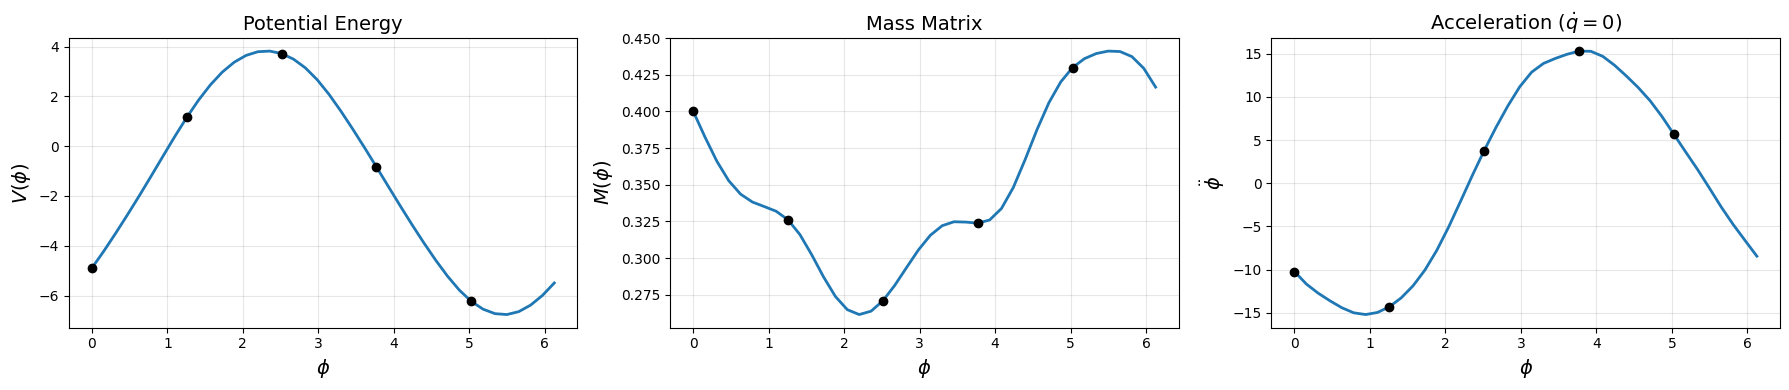

In [17]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# 1. Setup Inputs (0 to 2pi)
# We need 'requires_grad=True' to calculate acceleration via derivatives
q_range = np.linspace(0, 2*np.pi, 41)
q_tensor = torch.tensor(q_range[:-1], dtype=torch.float32, requires_grad=True)

# Create cos/sin inputs
cos_q = torch.cos(q_tensor)
sin_q = torch.sin(q_tensor)
cos_q_sin_q = torch.stack((cos_q, sin_q), axis=1)

# 2. Forward Pass (Get V and M)
V_pred = model.ode.V_net(cos_q_sin_q)
M_pred = model.ode.M_net(cos_q_sin_q) 

# 3. Calculate Acceleration
# Physics: acc = - (1/M) * (dV/dq)
# Get gradient of V w.r.t q
d_V_dq = torch.autograd.grad(outputs=V_pred.sum(), inputs=q_tensor, create_graph=False)[0]

# Compute acceleration (ensure M is correct shape for division)
if M_pred.dim() > 1:
    M_pred_sq = M_pred.squeeze()
else:
    M_pred_sq = M_pred

acc_pred = -1.0 * (1.0 / M_pred_sq) * d_V_dq

# 4. Convert to Numpy
q_np = q_tensor.detach().cpu().numpy()
V_np = V_pred.detach().cpu().numpy().flatten()
M_np = M_pred.detach().cpu().numpy().flatten()
acc_np = acc_pred.detach().cpu().numpy().flatten()

# 5. Plotting Side-by-Side
fig, axs = plt.subplots(1, 3, figsize=(18, 4), dpi=100)
markers_on = [0, 8, 16, 24, 32] # Markers for visual tracking

# Helper for consistent style
def setup_plot(ax, x, y, title, ylabel):
    ax.plot(x, y, marker='o', markevery=markers_on, 
            markerfacecolor=(0,0,0,1), markeredgecolor=(0,0,0,1), linewidth=2)
    ax.set_xlabel(r"$\phi$", fontsize=14)
    ax.set_ylabel(ylabel, fontsize=14)
    ax.set_title(title, fontsize=14)
    ax.grid(True, alpha=0.3)

# Plot V_net
setup_plot(axs[0], q_np, V_np, "Potential Energy", r"$V(\phi)$")

# Plot M_net (The Mass Matrix)
setup_plot(axs[1], q_np, M_np, "Mass Matrix", r"$M(\phi)$")

# Plot Acceleration
setup_plot(axs[2], q_np, acc_np, "Acceleration ($\dot{q}=0$)", r"$\ddot{\phi}$")

plt.tight_layout()
plt.show()

In [18]:
print("\n\n=== DECODER (obs_net) ===")
for name, param in model.obs_net.named_parameters():
    print(f"\nLayer: {name} | Shape: {param.shape}")
    print(param.data)



=== DECODER (obs_net) ===

Layer: linear1.weight | Shape: torch.Size([100, 1])
tensor([[ 0.4158],
        [ 0.5219],
        [ 0.7349],
        [ 0.7674],
        [-0.1467],
        [ 0.7424],
        [ 0.5048],
        [ 0.2032],
        [ 0.8617],
        [-0.7839],
        [-0.3709],
        [ 0.0018],
        [ 0.6487],
        [-0.4353],
        [ 0.5020],
        [-0.0151],
        [ 0.4455],
        [ 0.7325],
        [ 0.0775],
        [ 0.4026],
        [-0.2174],
        [-0.6914],
        [ 0.5625],
        [ 0.9319],
        [-0.8370],
        [ 0.2185],
        [-0.6009],
        [ 0.6732],
        [ 0.2419],
        [-0.3833],
        [-0.0698],
        [ 0.7545],
        [-0.4971],
        [-0.2653],
        [ 0.5613],
        [-0.8365],
        [-0.4948],
        [-0.0283],
        [ 0.0590],
        [ 0.4793],
        [-0.5115],
        [ 0.4905],
        [-0.2946],
        [-0.0239],
        [-0.5992],
        [ 0.5662],
        [-0.4663],
        [-0.4011],
       

## Plot 5 reconstruction images corresponding to the black dots

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.19916469..1.5144349].


torch.Size([60, 256, 32, 32])
torch.Size([40, 1, 32, 32])


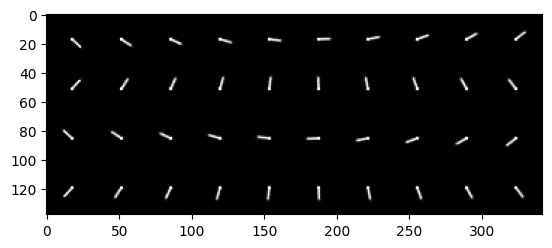

In [19]:
ones = torch.ones_like(cos_q_sin_q[:, 0:1])
content = model.obs_net(ones)

theta = model.get_theta_inv(cos_q_sin_q[:, 0], cos_q_sin_q[:, 1], 0, 0, bs=cos_q_sin_q.shape[0])
grid = F.affine_grid(theta, torch.Size((40, 1, 32, 32)))
Xrec = F.grid_sample(content.view(40, 1, 32, 32), grid)
print(model.Xrec.shape)
print(Xrec.shape)
fig = plt.figure()
grid = utils.make_grid(Xrec.view(40, 1, 32, 32), nrow=10)
plt.imshow(grid.permute(1,2,0).detach().cpu().numpy())

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.19916469..1.5144349].


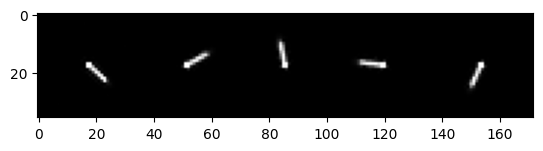

In [20]:
# for i in [0, 8, 16, 24, 32]:
#     fig = plt.figure()
#     plt.imshow(Xrec[i][0].detach().cpu().numpy(), cmap='gray')
#     plt.axis('off')
#     fig.savefig(os.path.join(PARENT_DIR, 'figures', f'pend_recon_{i}.png'), bbox_inches='tight')
grid = utils.make_grid(Xrec[0:40:8])
plt.imshow(grid.permute(1,2,0).detach().cpu().numpy())

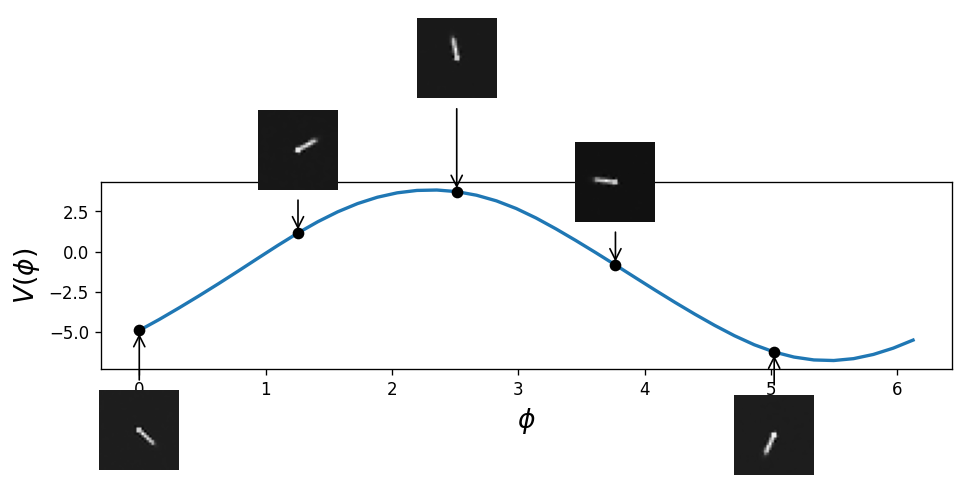

In [21]:
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

# ... (Run your existing data generation code for q, V_q, and Xrec here) ...

# 1. Setup the main figure
fig, ax = plt.subplots(figsize=(8, 4), dpi=120)

# 2. Plot the Potential Energy Curve
markers_on = [0, 8, 16, 24, 32]
ax.plot(q[:-1], V_q, marker='o', markevery=markers_on, 
        markerfacecolor='black', markeredgecolor='black', linewidth=2)

ax.set_xlabel(r"$\phi$", fontsize=16)
ax.set_ylabel(r"$V(\phi)$", fontsize=16)

# 3. Define offsets for the images to match the visual style of your upload
# (dx, dy) in 'points' relative to the data point. 
# You can tweak these to move the images up/down/left/right.
offsets = [
    (0, -60),  # Index 0:  Move image Down
    (0, 50),   # Index 8:  Move image Up
    (0, 80),   # Index 16: Move image Up (Longer arrow for the valley)
    (0, 50),   # Index 24: Move image Up
    (0, -50)   # Index 32: Move image Down
]

# 4. Loop through markers and overlay images
for i, idx in enumerate(markers_on):
    # Get the coordinate on the curve
    x_curr = q[idx]
    y_curr = V_q[idx]
    
    # Extract the image from Xrec (assuming shape [N, C, H, W])
    # We take the first channel [0] to get a 2D array (32x32)
    img_array = Xrec[idx, 0].detach().cpu().numpy()
    
    # Create an off-set image box
    # zoom controls the size of the thumbnail
    imagebox = OffsetImage(img_array, zoom=1.5, cmap='gray') 
    
    # Create the annotation
    # xy is the data point (dot), xybox is where the image sits
    ab = AnnotationBbox(imagebox, (x_curr, y_curr),
                        xybox=offsets[i],
                        boxcoords="offset points",
                        arrowprops=dict(arrowstyle="->", color='black'),
                        frameon=False) # Remove the box border around the image
    
    ax.add_artist(ab)

# Clean up layout
plt.tight_layout()
plt.show()

In [22]:
# import torch
# import numpy as np
# import matplotlib.pyplot as plt

# # 1. Define a range of angles from -pi to pi
# q_range = np.linspace(-np.pi, np.pi, 41)
# cos_q = np.cos(q_range)
# sin_q = np.sin(q_range)

# # 2. Prepare input for the V_net (batch_size x 2)
# # The network expects [cos_q, sin_q]
# inputs = torch.tensor(np.stack([cos_q, sin_q], axis=1), dtype=torch.float32)

# # 3. Pass through the frozen/retrained V_net
# # Assuming 'model' is your loaded Lagrangian_caVAE model
# V_learned_tensor = model.ode.V_net(inputs)
# V_learned = V_q.detach().cpu().numpy().flatten()
# print(V_learned)

In [23]:
# 4. Define known original potential (e.g., standard gravity)
# Adjust 'm', 'g', 'l' to match your simulation's units
V_original = np.load('v_learned_data.npy')

# 5. Compute the residual (The Perturbation)
# Align the minimums to 0 to remove arbitrary constants
V_q_aligned = V_q- np.min(V_q)
V_original_aligned = V_original - np.min(V_original)

# If the scales match (ideal case):
V_perturbation_data = V_q - V_original

print(V_perturbation_data)

# If scales might differ, you might need to find a scaling factor 'alpha':
# alpha = np.mean(V_learned_aligned) / np.mean(V_original_aligned)
# V_perturbation_data = V_learned_aligned - alpha * V_original_aligned

[[-10.189538  ]
 [-10.972115  ]
 [-11.502483  ]
 [-11.749795  ]
 [-11.697473  ]
 [-11.339865  ]
 [-10.679963  ]
 [ -9.730931  ]
 [ -8.513208  ]
 [ -7.0518365 ]
 [ -5.3887606 ]
 [ -3.5968966 ]
 [ -1.7571466 ]
 [  0.07622433]
 [  1.868195  ]
 [  3.580285  ]
 [  5.162835  ]
 [  6.5621157 ]
 [  7.7351856 ]
 [  8.662942  ]
 [  9.352715  ]
 [  9.824065  ]
 [ 10.08247   ]
 [ 10.112852  ]
 [  9.901926  ]
 [  9.45098   ]
 [  8.77222   ]
 [  7.8829336 ]
 [  6.798895  ]
 [  5.536493  ]
 [  4.1236777 ]
 [  2.6012845 ]
 [  1.010448  ]
 [ -0.6188097 ]
 [ -2.2590098 ]
 [ -3.865213  ]
 [ -5.384655  ]
 [ -6.7853227 ]
 [ -8.05931   ]
 [ -9.202285  ]]


/Users/harshit/miniconda3/envs/lagrangian_clean/lib/python3.9/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
Compiling Julia backend...
/Users/harshit/miniconda3/envs/lagrangian_clean/lib/python3.9/site-packages/pysr/sr.py:1873: UserWarning: Note: Setting `random_state` without also setting `deterministic=True` and `parallelism='serial'` will result in non-deterministic searches.
  warnings.warn(
[ Info: Started!
[ Info: Final population:
[ Info: Results saved to:


───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           6.017e+01  0.000e+00  y = -0.52997
3           5.207e+01  7.228e-02  y = x₀ + -3.5941
5           5.031e+01  1.719e-02  y = (x₀ + -3.3698) * 1.7318
6           2.127e+01  8.607e-01  y = 3.506 - square(3.9288 - x₀)
8           9.215e+00  4.183e-01  y = 6.9864 - (square(x₀ - 3.4598) * 2.182)
10          1.865e+00  7.989e-01  y = -14.373 - (square(x₀ * (x₀ + -7.0879)) * -0.14818)
11          6.091e-01  1.119e+00  y = -10.554 - (square(square(x₀ * (x₀ + -7.2052))) * -0.00...
                                      076074)
12          1.029e-01  1.778e+00  y = -12.2 - (square((x₀ + -0.50323) * (x₀ + -6.6665)) * -0...
                                      .24592)
14          1.029e-01  1.710e-04  y = -11.903 - ((square((x₀ + -6.6678) * (x₀ + -0.5033)) * ...
                                      -0.24577) + 0.3023)
───────────────────────────

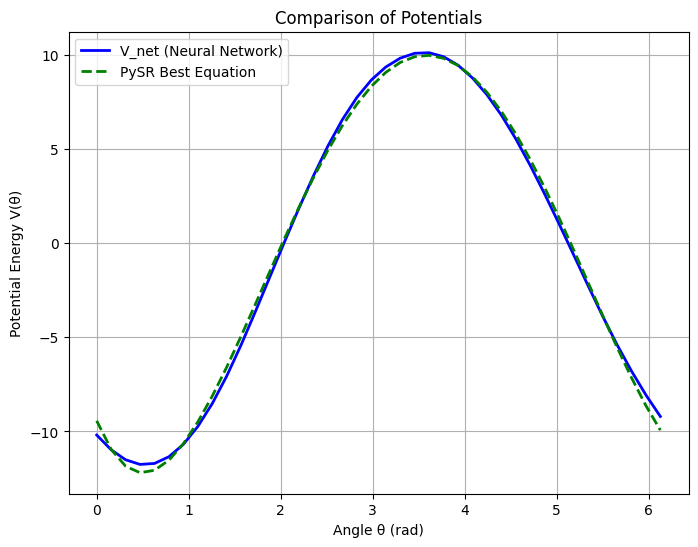

  - outputs/20260302_122415_72GBEb/hall_of_fame.csv


In [24]:
from pysr import PySRRegressor
# model_sr = PySRRegressor(
#     niterations=1000,
#     # REMOVE "sin" and "cos". 
#     # This forces it to use +, -, *, / to build polynomials.
#     binary_operators=["+", "*", "-", "/"],
#     unary_operators=["sin", "cos", "exp", "square"],
#     model_selection="best",
#     progress=False,
#     parsimony=0.01,
#     nested_constraints={
#         "sin": {"sin": 0, "cos": 0, "exp": 0},
#         "cos": {"sin": 0, "cos": 0, "exp": 0},
#         "exp": {"sin": 0, "cos": 0, "exp": 0},
#     },
# )
# model_sr.fit(q_range.reshape(-1, 1), V_perturbation_data)
# print(model_sr)
pysr_model = PySRRegressor(
        niterations=100,
        binary_operators=["+", "-", "*"],
        unary_operators=["square"],
        denoise=False,
        model_selection="best",
        maxsize=15,
        parsimony=0.01,
        random_state=42,
        procs=4,
    )

X = q_range.reshape(-1, 1)
pysr_model.fit(q[:-1].reshape(-1, 1), V_perturbation_data)
    
print("\n================== PySR Result ==================")
print(pysr_model)
print("=================================================")
    
    # Predict the PySR equation on X for plotting
pysr_pred = pysr_model.predict(q[:-1].reshape(-1, 1))
best_equation = str(pysr_model.sympy())
print("\n================== PySR pred ==================")
print(best_equation)
print("=================================================")

plt.figure(figsize=(8, 6))
plt.plot(q[:-1], V_perturbation_data, 'b-', linewidth=2, label='V_net (Neural Network)')
plt.plot(q[:-1], pysr_pred, 'g--', linewidth=2, label='PySR Best Equation')
# plt.plot(q_range, V_true, 'r:', linewidth=2, label='True Dynamics Potential (-15*M*cosθ)')
plt.xlabel('Angle θ (rad)')
plt.ylabel('Potential Energy V(θ)')
plt.title('Comparison of Potentials')
plt.legend()
plt.grid(True)
plt.show()

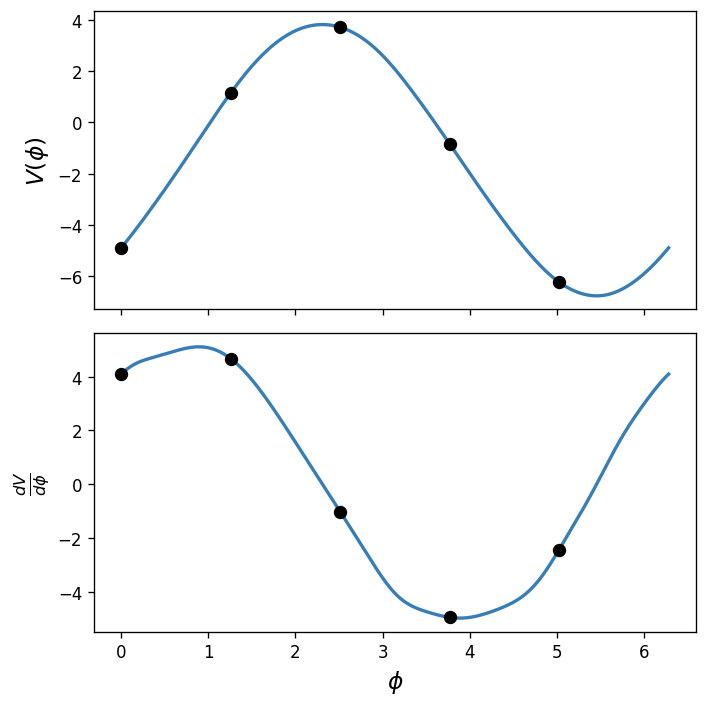

In [25]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# User's constants
DPI = 120

# ==========================================
# 1. PREPARE DATA
# ==========================================

# --- A. Dense Grid (For the smooth blue curve) ---
# We use 500 points to ensure the line looks like a curve, not polygons.
q_dense_np = np.linspace(0, 2*np.pi, 500)
q_dense = torch.tensor(q_dense_np, dtype=torch.float32, requires_grad=True)

# Compute inputs on the dense grid
cos_dense = torch.cos(q_dense)
sin_dense = torch.sin(q_dense)
x_dense = torch.stack((cos_dense, sin_dense), dim=1)


# --- B. Sparse Grid (For the black markers) ---
# This matches your original 40-point resolution logic
q_sparse_np = np.linspace(0, 2*np.pi, 41)[:-1] 
q_sparse = torch.tensor(q_sparse_np, dtype=torch.float32, requires_grad=True)

# Compute inputs on the sparse grid
cos_sparse = torch.cos(q_sparse)
sin_sparse = torch.sin(q_sparse)
x_sparse = torch.stack((cos_sparse, sin_sparse), dim=1)


# ==========================================
# 2. MODEL PASS & AUTOGRAD
# ==========================================
model.eval() # Important: Disables Dropout/BatchNorm noise

def get_V_and_grad(q_input, x_input):
    """Helper to forward pass and calculate gradient for any input resolution."""
    # 1. Forward Pass
    V_pred = model.ode.V_net(x_input)
    
    # 2. Backward Pass (Gradient)
    # We differentiate V_pred w.r.t q_input
    grads = torch.autograd.grad(
        outputs=V_pred,
        inputs=q_input,
        grad_outputs=torch.ones_like(V_pred),
        create_graph=False
    )[0]
    
    return V_pred.detach().cpu().numpy(), grads.detach().cpu().numpy()

# Calculate smooth curves
V_curve, dV_curve = get_V_and_grad(q_dense, x_dense)

# Calculate specific marker points
V_markers, dV_markers = get_V_and_grad(q_sparse, x_sparse)


# ==========================================
# 3. PLOTTING
# ==========================================
fig, ax = plt.subplots(2, 1, figsize=[6, 6], dpi=DPI, sharex=True)
markers_idx = [0, 8, 16, 24, 32] # Indices for the sparse array

# --- Top Plot: V(phi) ---
# 1. Plot the high-res line (Smooth)
ax[0].plot(q_dense_np, V_curve, color='#377eb8', linewidth=2)
# 2. Overlay the low-res markers
ax[0].plot(q_sparse_np[markers_idx], V_markers[markers_idx], 
           marker='o', linestyle='None', # 'None' prevents drawing lines between dots
           markerfacecolor='black', markeredgecolor='black', markersize=7)
ax[0].set_ylabel(r"$V(\phi)$", fontsize=14)

# --- Bottom Plot: dV/dphi ---
# 1. Plot the high-res line (Smooth) - THIS FIXES THE KINKS
ax[1].plot(q_dense_np, dV_curve, color='#377eb8', linewidth=2)
# 2. Overlay the low-res markers
ax[1].plot(q_sparse_np[markers_idx], dV_markers[markers_idx], 
           marker='o', linestyle='None', 
           markerfacecolor='black', markeredgecolor='black', markersize=7)
ax[1].set_ylabel(r"$\frac{dV}{d\phi}$", fontsize=14)
ax[1].set_xlabel(r"$\phi$", fontsize=14)

plt.tight_layout()
plt.show()

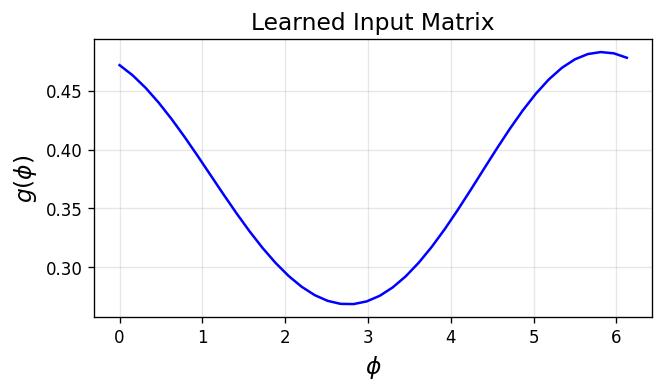

In [26]:
# 1. Prepare inputs (0 to 2pi) - effectively reusing the setup from the V_net cell
q = np.linspace(0, 2*np.pi, 41)
cos_q = np.cos(q[:-1])
sin_q = np.sin(q[:-1])
cos_q_sin_q = np.stack((cos_q, sin_q), axis=1)
cos_q_sin_q = torch.tensor(cos_q_sin_q, dtype=torch.float32)

# 2. Forward pass through g_net
# The model instance (loaded from checkpoint) contains the ode module, which holds g_net
g_q = model.ode.g_net(cos_q_sin_q).detach().cpu().numpy()

# 3. Plot
fig = plt.figure(figsize=[6, 3], dpi=DPI)
plt.plot(q[:-1], g_q, 'b-') # Plotting g(phi) vs phi
plt.xlabel(r"$\phi$", fontsize=14)
plt.ylabel(r"$g(\phi)$", fontsize=14)
plt.title("Learned Input Matrix", fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

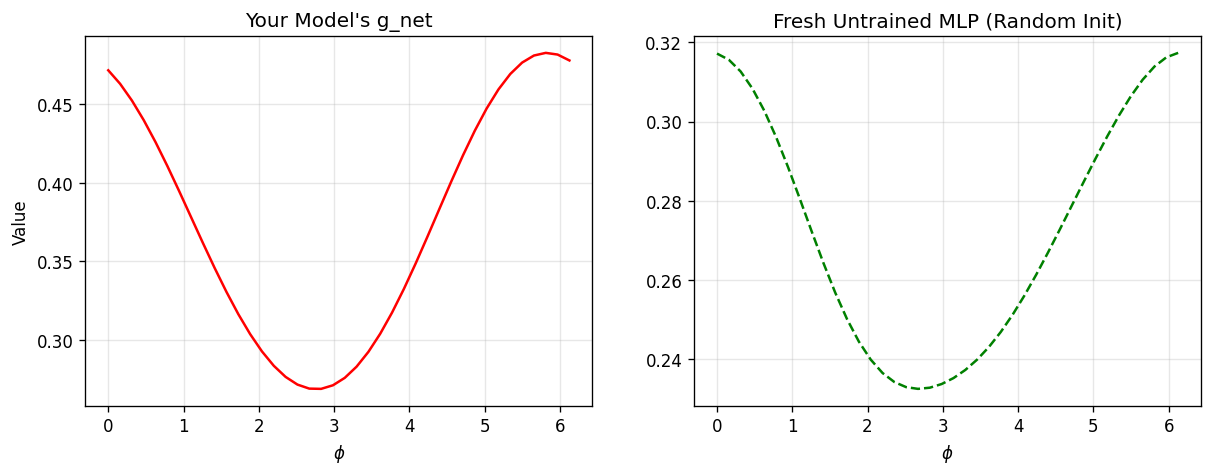

In [27]:
# 1. Plot the "Learned" g_net (from your loaded model)
q = np.linspace(0, 2*np.pi, 41)
cos_q = np.cos(q[:-1])
sin_q = np.sin(q[:-1])
cos_q_sin_q = torch.tensor(np.stack((cos_q, sin_q), axis=1), dtype=torch.float32)

g_learned = model.ode.g_net(cos_q_sin_q).detach().cpu().numpy()

# 2. Create a FRESH, UNTRAINED g_net (Random Initialization)
# Using the same architecture as defined in pend_lag_cavae_trainer.py
from lag_caVAE.nn_models import MLP
fresh_g_net = MLP(input_dim=2, hidden_dim=50, output_dim=1) 
g_random = fresh_g_net(cos_q_sin_q).detach().cpu().numpy()

# 3. Compare visually
fig, ax = plt.subplots(1, 2, figsize=(12, 4), dpi=DPI)

# Plot A: Your model
ax[0].plot(q[:-1], g_learned, 'r-', label='Model g_net (u=0 trained)')
ax[0].set_title("Your Model's g_net")
ax[0].set_xlabel(r"$\phi$")
ax[0].set_ylabel("Value")
ax[0].grid(alpha=0.3)

# Plot B: A completely random network
ax[1].plot(q[:-1], g_random, 'g--', label='Fresh Random MLP')
ax[1].set_title("Fresh Untrained MLP (Random Init)")
ax[1].set_xlabel(r"$\phi$")
ax[1].grid(alpha=0.3)

plt.show()

In [28]:
print(model.ode.g_net.linear1.weight[49, :5])
print("Fresh Random Net (linear1):")
print(fresh_g_net.linear1.weight[0, :5])

tensor([-0.1875,  0.1331], grad_fn=<SliceBackward0>)
Fresh Random Net (linear1):
tensor([-0.1059, -0.2184], grad_fn=<SliceBackward0>)


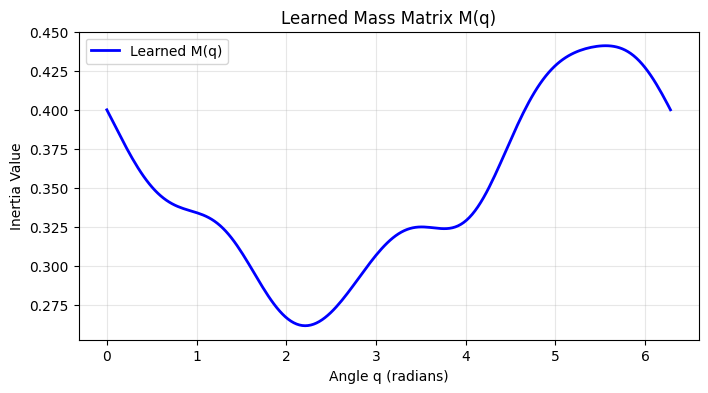

In [29]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def plot_learned_mass(model):
    # 1. Generate a range of angles (q) from -pi to pi
    angles = np.linspace(0, 2*np.pi, 200)
    
    # 2. Prepare inputs: M_net expects [cos(q), sin(q)]
    # We cannot just feed the angle; the network is designed to work with trig values
    cos_q = np.cos(angles)
    sin_q = np.sin(angles)
    
    # Stack them into a tensor of shape (Batch_Size, 2)
    inputs_np = np.stack([cos_q, sin_q], axis=1)
    inputs = torch.tensor(inputs_np, dtype=torch.float32).to(model.device)

    # 3. Pass through the M_net
    model.eval() # Set to evaluation mode
    with torch.no_grad():
        # Access the mass network inside the ODE module
        # M_net outputs shape (Batch, 1) for a 1D pendulum
        mass_matrix = model.ode.M_net(inputs)

    # 4. Plot
    mass_values = mass_matrix.cpu().numpy().flatten()
    
    plt.figure(figsize=(8, 4))
    plt.plot(angles, mass_values, label='Learned M(q)', color='blue', linewidth=2)
    
    # Add labels
    plt.xlabel('Angle q (radians)')
    plt.ylabel('Inertia Value')
    plt.title('Learned Mass Matrix M(q)')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

# Assuming your model variable is named 'model'
plot_learned_mass(model)

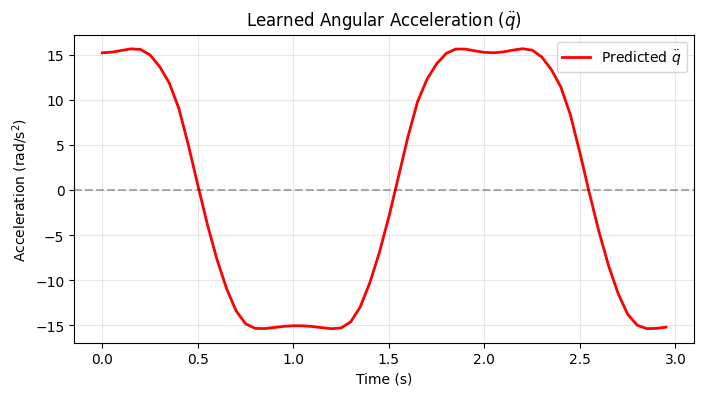

Text(0, 0.5, 'q_ddot')

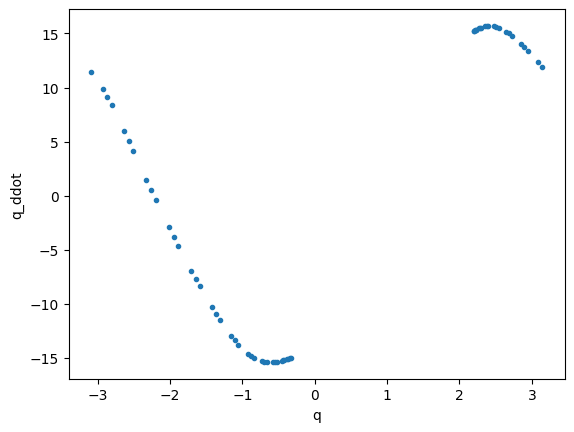

In [23]:
import torch
import matplotlib.pyplot as plt
from torchdiffeq import odeint

# 1. Prepare the model and input
model.eval()
z0_u = torch.cat((model.q0, model.q_dot0, u), dim=1).detach()
# We must enable gradients for the state so the Lagrangian physics work
z0_u.requires_grad = True 

# 2. Re-simulate the latent trajectory
# We explicitly enable grad here so model.ode can call torch.autograd.grad
with torch.set_grad_enabled(True):
    z_traj = odeint(model.ode, z0_u, model.t_eval, method=model.hparams.solver)

# 3. Compute the acceleration (q_double_dot)
T_steps, batch_size, _ = z_traj.shape
# Re-evaluate the ODE on the trajectory to extract derivatives
# We use set_grad_enabled(True) again for the internal autograd calls
with torch.set_grad_enabled(True):
    z_flat = z_traj.reshape(-1, 4)
    t_flat = torch.zeros(z_flat.shape[0], device=z_flat.device)
    dz_dt_flat = model.ode(t_flat, z_flat)

# 4. Extract q_double_dot (index 2)
# Detach now to convert to numpy for plotting
q_ddot = dz_dt_flat[:, 2].detach().cpu().numpy()
q_ddot = q_ddot.reshape(T_steps, batch_size)
t_axis = model.t_eval.cpu().numpy()

# 5. Plotting
plt.figure(figsize=(8, 4), dpi=100)
plt.plot(t_axis, q_ddot[:, 0], 'r-', linewidth=2, label=r'Predicted $\ddot{q}$')
plt.axhline(0, color='black', linestyle='--', alpha=0.3)
plt.xlabel('Time (s)')
plt.ylabel(r'Acceleration (rad/s$^2$)')
plt.title('Learned Angular Acceleration ($\ddot{q}$)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
q = torch.atan2(z_traj[:,:,1], z_traj[:,:,0]).detach().cpu().numpy()
plt.plot(q[:,0], q_ddot[:,0], '.')
plt.xlabel("q")
plt.ylabel("q_ddot")

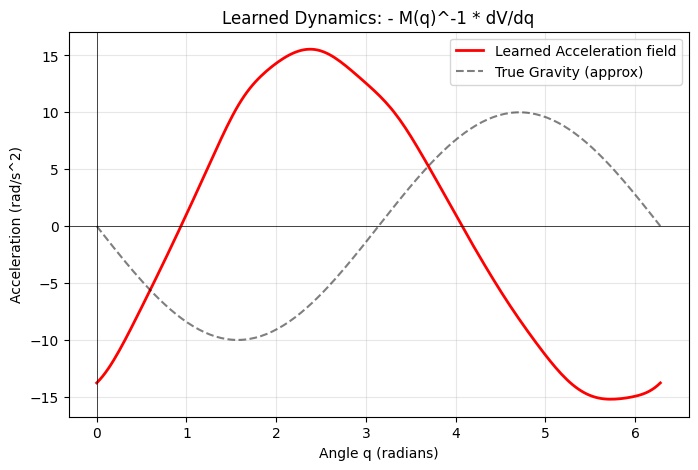

In [24]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def plot_potential_acceleration(model):
    # 1. Prepare inputs: Range of angles from -pi to pi
    angles = np.linspace(0, 2*np.pi, 200)
    
    # Create tensor for [cos(q), sin(q)]
    # IMPORTANT: We need requires_grad=True to calculate forces (gradients)
    cos_q = np.cos(angles)
    sin_q = np.sin(angles)
    inputs_np = np.stack([cos_q, sin_q], axis=1)
    inputs = torch.tensor(inputs_np, dtype=torch.float32).to(model.device)
    inputs.requires_grad_(True) 

    # 2. Compute Potential Energy (V) and its gradient (Force)
    # We don't use model.eval() here because we need grad for the physics calculation,
    # but we won't be updating weights.
    
    V_q = model.ode.V_net(inputs)
    
    # Calculate dV/d(input)
    # This gives [dV/d(cos), dV/d(sin)]
    dV_dinput = torch.autograd.grad(V_q.sum(), inputs, create_graph=False)[0]
    
    # Chain Rule to get dV/dq (Force w.r.t Angle)
    # dV/dq = (dV/dcos * -sin) + (dV/dsin * cos)
    dV_dcos = dV_dinput[:, 0]
    dV_dsin = dV_dinput[:, 1]
    
    sin_q_tensor = inputs[:, 1]
    cos_q_tensor = inputs[:, 0]
    
    dV_dq = dV_dcos * (-sin_q_tensor) + dV_dsin * (cos_q_tensor)

    # 3. Compute Mass (M)
    with torch.no_grad():
        M_q = model.ode.M_net(inputs)
        # Flatten M_q (it comes out as batch, 1, 1 for pendulum)
        M_q = M_q.view(-1)

    # 4. Calculate Acceleration Field
    # a = - (1/M) * (dV/dq)
    # We detach() to convert to numpy for plotting
    acceleration = (-dV_dq / M_q).detach().cpu().numpy()

    # 5. Plot
    plt.figure(figsize=(8, 5))
    plt.plot(angles, acceleration, label='Learned Acceleration field', color='red', linewidth=2)
    plt.plot(angles, -10 * np.sin(angles), 'k--', alpha=0.5, label='True Gravity (approx)')
    
    plt.axhline(0, color='black', linewidth=0.5)
    plt.axvline(0, color='black', linewidth=0.5)
    plt.xlabel('Angle q (radians)')
    plt.ylabel('Acceleration (rad/s^2)')
    plt.title('Learned Dynamics: - M(q)^-1 * dV/dq')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Run the function
plot_potential_acceleration(model)

In [25]:
import torch
import numpy as np

# 1. Define the standard angles (Identical to Step 1)
angles = np.linspace(0, 2*np.pi, 200)
cos_q = np.cos(angles)
sin_q = np.sin(angles)
inputs_np = np.stack([cos_q, sin_q], axis=1)

# 2. Calculate Acceleration
inputs = torch.tensor(inputs_np, dtype=torch.float32).to(model.device)
inputs.requires_grad_(True)

V = model.ode.V_net(inputs)
dV_input = torch.autograd.grad(V.sum(), inputs, create_graph=False)[0]
dV_dq = dV_input[:, 0] * (-inputs[:, 1]) + dV_input[:, 1] * (inputs[:, 0])

with torch.no_grad():
    M = model.ode.M_net(inputs).view(-1)

accel_new = (-dV_dq / M).detach().cpu().numpy()

# 3. Save to file
np.save('acceleration_new.npy', accel_new)
print("Saved 'acceleration_new.npy'.")

Saved 'acceleration_new.npy'.


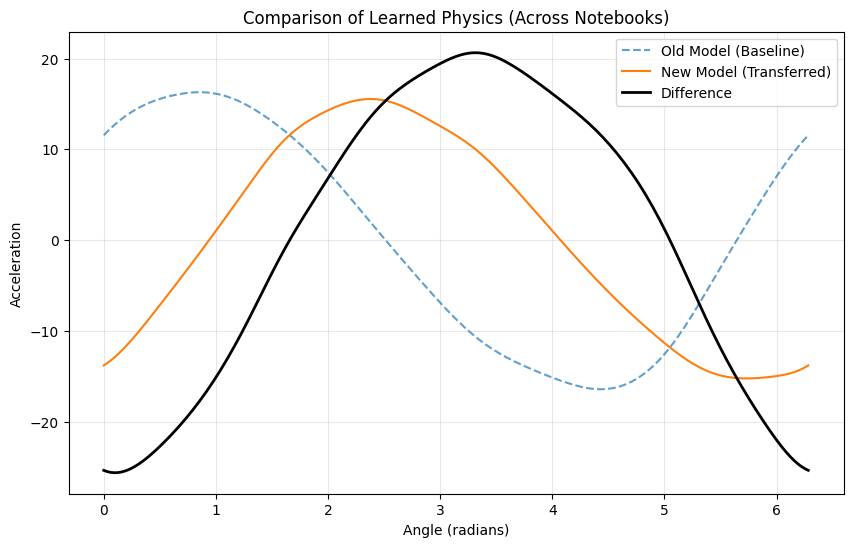

Mean Squared Error between models: 256.763092


In [26]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the data
accel_old = np.load('acceleration_old.npy')
accel_new = np.load('acceleration_new.npy')

# Re-create the angle array for plotting
angles = np.linspace(0, 2*np.pi, 200)

# 2. Plot Comparison
plt.figure(figsize=(10, 6))
plt.plot(angles, accel_old, '--', label='Old Model (Baseline)', alpha=0.7)
plt.plot(angles, accel_new, '-', label='New Model (Transferred)')
plt.plot(angles, accel_new - accel_old, 'k-', linewidth=2, label='Difference')

plt.title("Comparison of Learned Physics (Across Notebooks)")
plt.xlabel("Angle (radians)")
plt.ylabel("Acceleration")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 3. Mathematical Sanity Check
mse = np.mean((accel_old - accel_new)**2)
print(f"Mean Squared Error between models: {mse:.6f}")

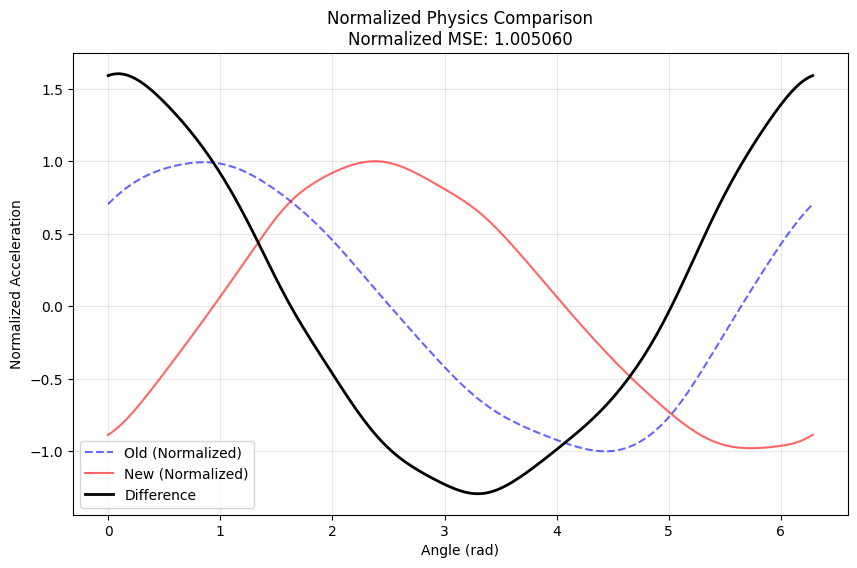

Normalized MSE: 1.005060
❌ FAILURE: The shapes still look different.
   The model did NOT learn the original dynamics correctly.


In [27]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the raw files
try:
    accel_old = np.load('acceleration_old.npy')
    accel_new = np.load('acceleration_new.npy')
except FileNotFoundError:
    print("❌ Error: Could not find .npy files. Make sure you ran Step 1 and 2!")
    raise

# 2. Normalize both curves
# We divide by the maximum absolute value to scale everything between -1 and 1.
# This cancels out the hidden 'Mass' multiplier.
norm_old = accel_old / np.max(np.abs(accel_old))
norm_new = accel_new / np.max(np.abs(accel_new))

# 3. Calculate Normalized MSE
mse_norm = np.mean((norm_old - norm_new)**2)

# 4. Plot Comparison
angles = np.linspace(0, 2*np.pi, 200)
plt.figure(figsize=(10, 6))
plt.plot(angles, norm_old, 'b--', label='Old (Normalized)', alpha=0.6)
plt.plot(angles, norm_new, 'r-', label='New (Normalized)', alpha=0.6)
plt.plot(angles, norm_old - norm_new, 'k-', linewidth=2, label='Difference')

plt.title(f"Normalized Physics Comparison\nNormalized MSE: {mse_norm:.6f}")
plt.xlabel("Angle (rad)")
plt.ylabel("Normalized Acceleration")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 5. The Verdict
print(f"Normalized MSE: {mse_norm:.6f}")
if mse_norm < 0.05:
    print("✅ SUCCESS: The shapes match! The high error was just a scaling issue.")
    print("   Your Transfer Learning worked correctly.")
else:
    print("❌ FAILURE: The shapes still look different.")
    print("   The model did NOT learn the original dynamics correctly.")

# Control

In [28]:
import gym, myenv
import numpy as np
from skimage import color
from gym import wrappers
env = gym.make('MyPendulum-v0')

# prepare model instance
model.hparams.solver = 'rk4'
model.bs = 1
model.d = 32

# get a goal image
q_star = 0.0
env.reset()
env.state = np.array([q_star, 0.0], dtype=np.float32)
goal_frame = env.render(mode='rgb_array')
goal_frame = color.rgb2gray(goal_frame)
goal_frame = torch.tensor(goal_frame, dtype=torch.float32)
env.close()

# given a goal image, design controller
# first encode the goal image to goal coordinates
_, _, goal_q_n = model.encode(goal_frame.view(1, 32*32))

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/Users/harshit/Library/Python/3.9/lib/python/site-packages/gym/spaces/box.py:127: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")
/Users/harshit/Library/Python/3.9/lib/python/site-packages/gym/utils/passive_env_checker.py:174: UserWarning: WARN: Future gym versions will require that `Env.reset` can be passed a `seed` instead of using `Env.seed` for resetting the environment random number generator.
  lo

AttributeError: 'CocoaAlternateEventLoop' object has no attribute 'platform_event_loop'

In [ ]:
goal_q_n

In [ ]:
q0 = 3.14

env.reset()
env.state = np.array([q0, 0.0], dtype=np.float32)
frame = color.rgb2gray(env.render(mode='rgb_array'))
frames = [frame]

frame = torch.tensor(frame, dtype=torch.float32)

for i in range(100):
    _, _, q_n = model.encode(frame.view(1, 32*32))
    
    if i==0:
        prev_q_n = q_n
        
    q_dot = model.angle_vel_est(prev_q_n, q_n, 0.05)

    V_q = model.ode.V_net(q_n)
    dV = torch.autograd.grad(V_q, q_n)[0]
    dV_dcos_q, dV_dsin_q = dV.split([1, 1], dim=1)
    dV_dq = - dV_dcos_q * q_n[:, 1] + dV_dsin_q * q_n[:, 0]
    g_q = model.ode.g_net(q_n)

#     energy_shaping = torch.zeros(2, 1, dtype=torch.float32)
#     energy_shaping[0][0] = dV_dr[0][0] - 3* (r_cos_phi_sin_phi[0][0] - 0.0)
#     energy_shaping[1][0] = 2 * dV_dphi[0][0]

    energy_shaping = dV_dq - 6 * (q_n[0, 1] * goal_q_n[0, 0] - q_n[0, 0] * goal_q_n[0, 1])
    damping_injection = - 1 * q_dot.T

    u = 1/g_q * (energy_shaping + damping_injection)

    u = u.detach().cpu().numpy()
    env.step(u)

    frame = color.rgb2gray(env.render(mode='rgb_array'))
    frames.append(frame)
    frame = torch.tensor(frame, dtype=torch.float32)

    prev_q_n = q_n

env.close()

NameError: name 'frames' is not defined

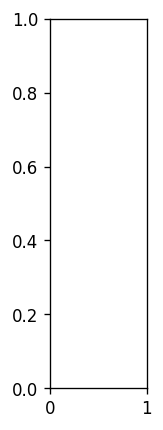

In [29]:
fig = plt.figure(figsize=(16, 4), dpi=DPI)
for i in range(13):
    plt.subplot(1, 13, i+1)
    plt.imshow(frames[i*8], cmap='gray')
    plt.axis('off')
    
# fig.savefig(os.path.join(PARENT_DIR, 'figures', 'pend-ctrl.png'), bbox_inches='tight')

In [30]:
# import imageio
# imageio.mimsave(os.path.join(PARENT_DIR, 'figures', 'pend-ctrl.gif'), frames, duration=0.05)

control animation ![control sequence](../figures/pend-ctrl.gif)

In [31]:
model.hparams

"T_pred":                            4
"accelerator":                       None
"accumulate_grad_batches":           None
"amp_backend":                       native
"amp_level":                         None
"annealing":                         False
"auto_lr_find":                      False
"auto_scale_batch_size":             False
"auto_select_gpus":                  False
"batch_size":                        512
"benchmark":                         False
"check_val_every_n_epoch":           1
"checkpoint_callback":               None
"default_root_dir":                  None
"detect_anomaly":                    False
"deterministic":                     False
"devices":                           None
"enable_checkpointing":              True
"enable_model_summary":              True
"enable_progress_bar":               True
"fast_dev_run":                      False
"flush_logs_every_n_steps":          None
"gpus":                              1
"gradient_clip_algorithm":        